# Run Model Notebook

Lean runner for a single-country simulation. Update **Inputs**, then run the main workflow cells from top to bottom. Optional benchmark, Monte Carlo, sensitivity, and appendix diagnostics can be run manually.

In [1]:
# git checkout 89 ----repo INET-Complexity/macro-main

## Sections
- Setup
- Inputs
- Prepare Data
- Configure Scenario
- Run Simulation
- Plots
- Optional Benchmark
- Optional Monte Carlo
- Optional Sensitivity
- Appendix

In [ ]:
# Setup
%load_ext autoreload
%autoreload 2

import logging

import numpy as np

from src.monte_carlo import run_seeded_monte_carlo
from src.notebook_workflow import (
    NotebookRunConfig,
    build_country_config,
    prepare_data,
    run_benchmark,
    run_single_simulation,
)
from src.sensitivity import run_parameter_sensitivity
from src.visual_helpers import (
    build_cpi_comparison_df,
    build_ppi_comparison_df,
    plot_cpi_comparison,
    plot_employment_by_sector,
    plot_housing_market_aggregates,
    plot_mc,
    plot_output,
    plot_ppi_comparison,
    plot_sectoral_prices_over_time,
    plot_sensitivity,
    plot_sensitivity_summary,
    plot_production_by_sector
)

logging.getLogger().setLevel(logging.ERROR)

In [3]:
# Inputs
run_config = NotebookRunConfig(
    seed=16,
    t_max=50,
    country_iso3="FRA",
    run_benchmark=True,
    force_rebuild_data=True,
    force_rerun_benchmark=True,
    benchmark_overrides=None,  # use country_config_FRA.yaml unchanged
)

scenario_overrides = {
    # "labour_market.functions.clearing.name": "ReservationWageBindingDefaultLabourMarketClearer",
    # "labour_market.functions.clearing.parameters['allow_switching_industries']":  True,
    # "housing_market.functions.clearing.name": "NoHousingMarketClearer",
    # "firms.functions.prices.parameters['price_setting_speed_dp']": 0.25,
    # "firms.functions.prices.parameters['price_setting_speed_cp']": 0.1,
    "firms.parameters.['intermediate_inputs_utilisation_rate']": 0.65,
    # "firms.parameters.['capital_inputs_utilisation_rate']": 0.65,
    # "firms.functions.production.name": "CriticalAndImportantLeontief",
}

In [4]:
# Prepare Data
prepared = prepare_data(run_config)
cfg = prepared.cfg
data = prepared.data
creator = prepared.creator
na = prepared.national_accounts

{'seed': 16, 'country': 'FRA', 't_max': 50, 'raw_data_path': '/Users/andone/Documents/python_projects/INET-consumption/run_model/data/raw_data', 'output_dir': '/Users/andone/Documents/python_projects/INET-consumption/run_model/data/output_data', 'data_cache': '/Users/andone/Documents/python_projects/INET-consumption/run_model/data/output_data/data.pkl'}


In [5]:
# Configure Scenario
country_configurations = build_country_config(
    data=data,
    config=run_config,
    overrides=scenario_overrides,
)

Configuration summary
{'productivity_growth': 'SimpleTFPGrowth',
 'productivity_investment_planner': 'TargetIntensityTFPInvestmentPlanner',
 'labour_market': {'name': 'DefaultLabourMarketClearer',
                   'parameters': {'allow_switching_industries': True,
                                  'compare_with_normalised_inputs': True,
                                  'consider_reservation_wages': True,
                                  'firing_cost_fraction': 0.0,
                                  'firing_speed': 1.0,
                                  'hiring_cost_fraction': 0.0,
                                  'hiring_speed': 0.75,
                                  'individuals_quitting': False,
                                  'individuals_quitting_temperature': 1.0,
                                  'optimised_hiring': True,
                                  'random_firing_probability': 0.0,
                                  'round_target_employment': True,
                 

In [6]:
# Run Simulation
simulation = run_single_simulation(
    data=data,
    country_configurations=country_configurations,
    config=run_config,
)
model = simulation.model
df_base = simulation.df_base

/Users/andone/Documents/python_projects/INET-consumption/run_model/src/notebook_workflow.py:314: UserWarning: Configuration mismatch for FRA. Resetting firm-dependent synthetic data. Mismatches: firms.intermediate_inputs_utilisation_rate: data_config=0.85, country_config=0.65
  model = Simulation.from_datawrapper(datawrapper=data, simulation_configuration=simulation_config)


Simulation complete. Output saved to: /Users/andone/Documents/python_projects/INET-consumption/run_model/data/output_data/simulation_FRA.h5


In [7]:
# Plots
plot_columns = [
    "total_consumption_to_gdp", "investment_to_gdp", "net_exports_to_gdp",
    "debt_to_gdp", "fiscal_revenue_to_gdp", "fiscal_expenditure_to_gdp", "deficit_to_gdp",
    "household_consumption_to_gdp", "government_consumption_to_gdp", "gdp", "real_gdp",
    "gdp_growth", "unemployment_rate", "central_bank_policy_rate",
    "wages", "profits", "cpi_transaction", "ppi", "cpi_transaction_yoy_change", "bank_insolvency_rate",
    "avg_tfp_multiplier",
]

plot_output(
    df=df_base[plot_columns],
    no_rows=5,
    no_cols=4,
    country_code=cfg.country_iso3,
    line_color="#1f77b4",
    base_height=220,
    base_width=380,
)

In [8]:
# Fiscal And Policy Plots
fiscal_cols = [
    "unemployment_benefits", "other_benefits", "government_consumption", "interest_payments_on_debt",
    "unemployment_benefits_to_expenditure", "other_benefits_to_expenditure",
    "government_consumption_to_expenditure", "interest_payments_on_debt_to_expenditure",
    "unemployment_rate", "cpi_transaction", "debt_to_gdp", "central_bank_policy_rate",
    "fiscal_expenditure", "deficit_to_gdp", "gdp_growth",
    "taxes_paid_on_production", "taxes_on_products", 
]
policy_cols = [
    "unemployment_rate", "cpi_fixed_basket_yoy_change", "ppi_yoy_change",
    "central_bank_policy_rate", "short_term_firm_borrowing_rate",
    "long_term_firm_borrowing_rate", "household_consumption_borrowing_rate", "mortgage_borrowing_rate",
    "short_term_loans_to_firms", "long_term_loans_to_firms", "consumption_loans_to_households", "mortgages_to_households",
]

plot_output(df=df_base[fiscal_cols], no_rows=5, no_cols=4, country_code=cfg.country_iso3, base_height=220, base_width=380)
plot_output(df=df_base[policy_cols], no_rows=4, no_cols=4, country_code=cfg.country_iso3, base_height=220, base_width=380)

In [ ]:
# Price And Sector Diagnostics
cpi_df = build_cpi_comparison_df(model, country_code=cfg.country_iso3)
ppi_df = build_ppi_comparison_df(model, country_code=cfg.country_iso3)
plot_cpi_comparison(cpi_df)
plot_ppi_comparison(ppi_df)
plot_sectoral_prices_over_time(model=model, country_code=cfg.country_iso3)
plot_sectoral_prices_over_time(model=model, country_code=cfg.country_iso3, kind="lines", print_sector_names=False)
plot_employment_by_sector(model, cfg.country_iso3, title="Employment by sector (model)")
plot_production_by_sector(model, cfg.country_iso3, title="Production by sector (model)")


Sector codes:
A: Agriculture, forestry and fishing
B: Mining and quarrying
C: Manufacturing
D: Electricity, gas, steam and air conditioning supply
E: Water supply; sewerage, waste management
F: Construction
G: Wholesale and retail trade
H: Transportation and storage
I: Accommodation and food service activities
J: Information and communication
K: Financial and insurance activities
L: Real estate activities
M: Professional, scientific and technical activities
N: Administrative and support service activities
O: Public administration and defence
P: Education
Q: Human health and social work activities
R_S: Arts, entertainment, recreation and other services


In [10]:
from src.visual_helpers import plot_cumulative_insolvent_firms_by_sector
plot_cumulative_insolvent_firms_by_sector(df_base)


In [11]:
# model.countries['FRA'].firms.ts.get_keys()

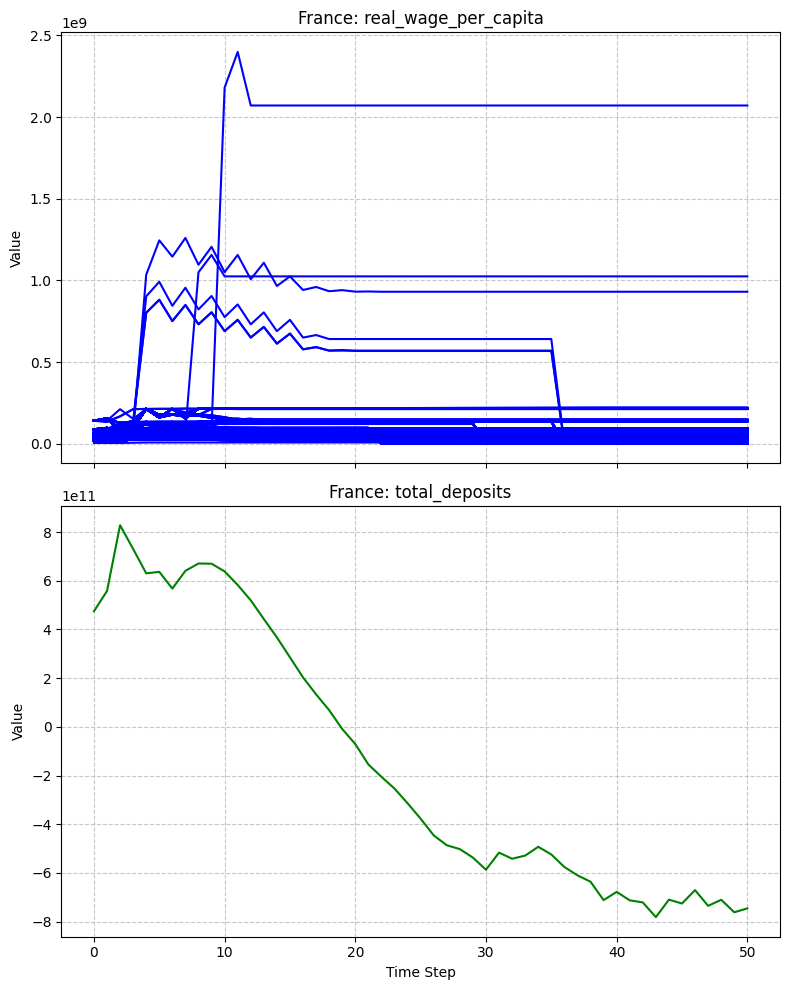

In [12]:
import matplotlib.pyplot as plt
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# Plot 1: Labour Productivity Factor
ax1.plot(model.countries['FRA'].firms.ts.real_wage_per_capita, color='blue')
ax1.set_title('France: real_wage_per_capita')
ax1.set_ylabel('Value')
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Labour Productivity
ax2.plot(model.countries['FRA'].firms.ts.total_deposits, color='green')
ax2.set_title('France: total_deposits')
ax2.set_ylabel('Value')
ax2.set_xlabel('Time Step')
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()



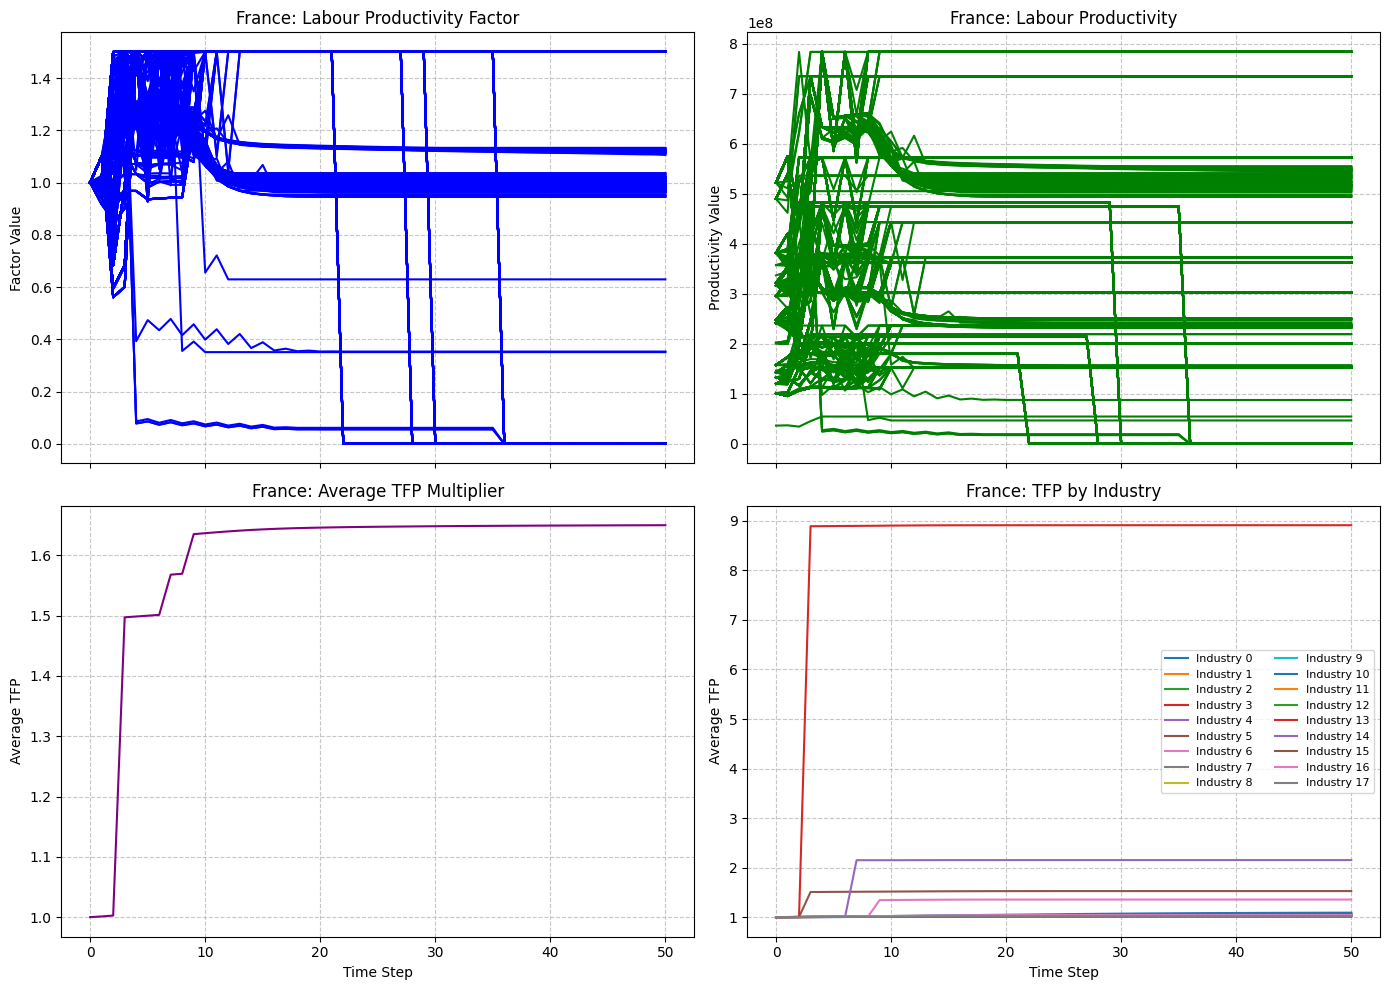

In [13]:
import numpy as np
import matplotlib.pyplot as plt

firms = model.countries["FRA"].firms

avg_tfp_multiplier = np.array([np.mean(x) for x in firms.ts.tfp_multiplier])

tfp_by_industry = np.array([
    [
        np.mean(tfp[industry_mask]) if industry_mask.any() else np.nan
        for industry_mask in [
            firms.states["Industry"] == ind
            for ind in range(firms.n_industries)
        ]
    ]
    for tfp in firms.ts.tfp_multiplier
])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

ax1, ax2, ax3, ax4 = axes.ravel()

# Plot 1: Labour Productivity Factor
ax1.plot(firms.ts.labour_productivity_factor, color="blue")
ax1.set_title("France: Labour Productivity Factor")
ax1.set_ylabel("Factor Value")
ax1.grid(True, linestyle="--", alpha=0.7)

# Plot 2: Labour Productivity
ax2.plot(firms.ts.labour_productivity, color="green")
ax2.set_title("France: Labour Productivity")
ax2.set_ylabel("Productivity Value")
ax2.grid(True, linestyle="--", alpha=0.7)

# Plot 3: Average TFP Multiplier
ax3.plot(avg_tfp_multiplier, color="purple")
ax3.set_title("France: Average TFP Multiplier")
ax3.set_ylabel("Average TFP")
ax3.set_xlabel("Time Step")
ax3.grid(True, linestyle="--", alpha=0.7)

# Plot 4: TFP by Industry
for ind in range(firms.n_industries):
    ax4.plot(tfp_by_industry[:, ind], label=f"Industry {ind}")

ax4.set_title("France: TFP by Industry")
ax4.set_ylabel("Average TFP")
ax4.set_xlabel("Time Step")
ax4.grid(True, linestyle="--", alpha=0.7)
ax4.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


In [14]:
from src.visual_helpers import (plot_agent_timeseries,
                                plot_credit_rationing, 
                                plot_firm_credit_to_equity_and_capital,
                                 plot_sector_tfp_investment_desired_mb_mc_ratio)


credit_cols = [
     'total_target_short_term_credit',
     'total_target_long_term_credit',
     'total_received_short_term_credit',
     'total_received_long_term_credit',
     'short_term_loan_debt',
     'long_term_loan_debt',
 ]

# 3 vars -> 2x2 grid (last panel empty)
plot_agent_timeseries(
    model, "FRA", "firms",
    variables=credit_cols,
    agg="sum",
    no_cols=2,          # usually best for long lists
    base_height=220,    # tighter panels
    base_width=360,
)

# plot_agent_timeseries(
#     model, "FRA", "firms",
#     ["target_short_term_credit", "received_short_term_credit",
#      "target_long_term_credit", "received_long_term_credit"],
#     agent_id=[1, 110, 220, 330],
#         no_cols=2,          # usually best for long lists
#     base_height=220,    # tighter panels
#     base_width=360,
# )

plot_agent_timeseries(
    model, "FRA", "banks",
    ["total_credit_supply_cap_firms_short_term", "total_credit_supply_cap_firms_long_term",
     "total_credit_supply_cap_households_consumption", "total_credit_supply_cap_mortgages"],
        no_cols=2,          # usually best for long lists
    base_height=260,    # tighter panels
    base_width=360,
)

plot_agent_timeseries(
    model, "FRA", "firms", 
    ['profits', 'expected_profits', 'total_wage', 'labour_costs', 'unit_costs', 
     'equity', 'capital_inputs_stock_value', 'intermediate_inputs_stock_value',
     'estimated_demand',  'demand', 'inventory', 
     'total_sales', 'total_debt', 'total_deposits'],
        no_cols=2,          # usually best for long lists
    base_height=260,    # tighter panels
    base_width=360,
)


plot_credit_rationing(model, "FRA", show=True)

plot_firm_credit_to_equity_and_capital(model, "FRA", show=True, return_df=False)

plot_sector_tfp_investment_desired_mb_mc_ratio(model, "FRA")


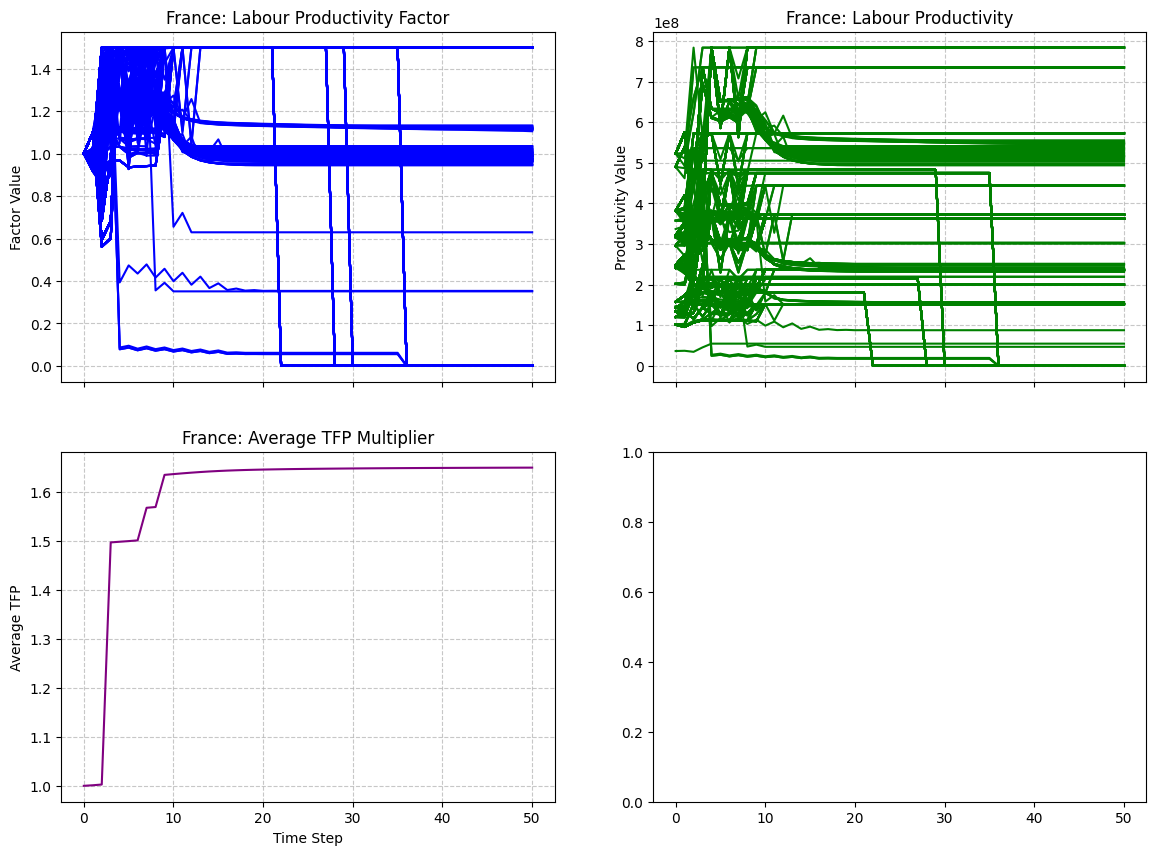

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

ax1, ax2, ax3, ax4 = axes.ravel()

# Plot 1: Labour Productivity Factor
ax1.plot(firms.ts.labour_productivity_factor, color="blue")
ax1.set_title("France: Labour Productivity Factor")
ax1.set_ylabel("Factor Value")
ax1.grid(True, linestyle="--", alpha=0.7)

# Plot 2: Labour Productivity
ax2.plot(firms.ts.labour_productivity, color="green")
ax2.set_title("France: Labour Productivity")
ax2.set_ylabel("Productivity Value")
ax2.grid(True, linestyle="--", alpha=0.7)

# Plot 3: Average TFP Multiplier
ax3.plot(avg_tfp_multiplier, color="purple")
ax3.set_title("France: Average TFP Multiplier")
ax3.set_ylabel("Average TFP")
ax3.set_xlabel("Time Step")
ax3.grid(True, linestyle="--", alpha=0.7)


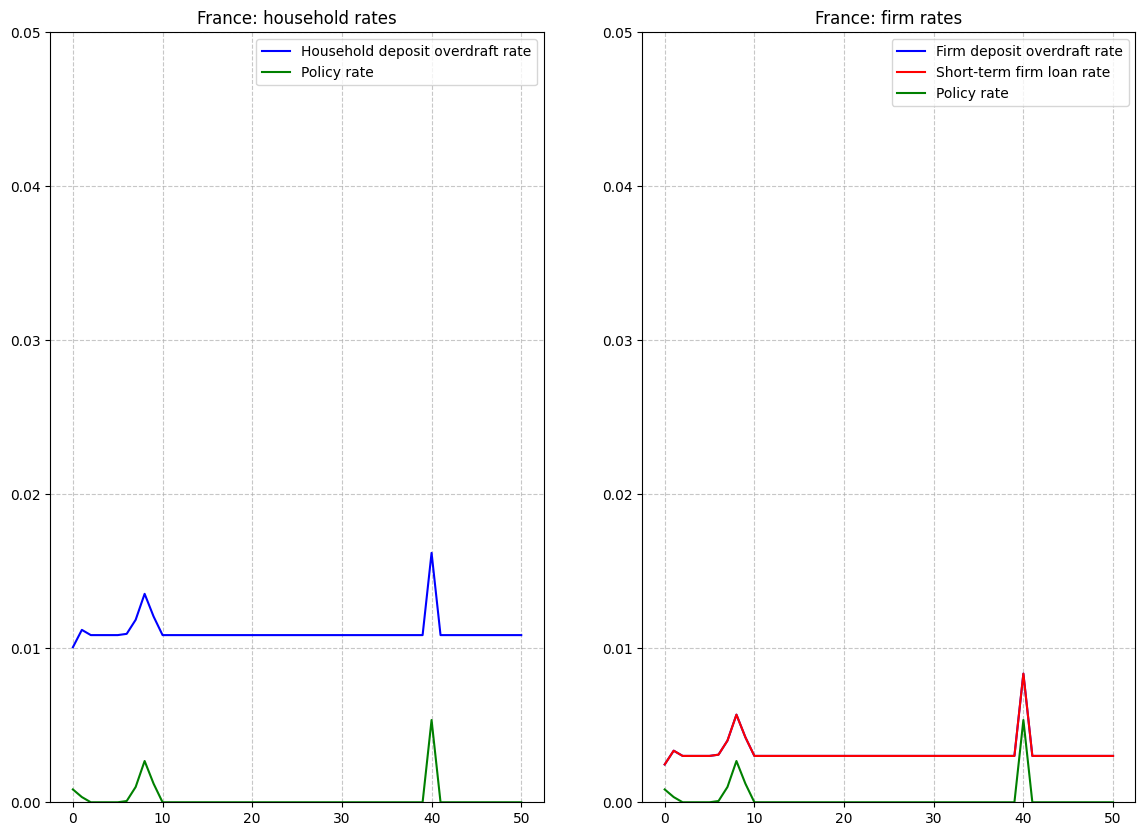

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharex=True)

ax1, ax2 = axes.ravel()

# Plot 1
ax1.plot(
    model.countries["FRA"].banks.ts.average_overdraft_rate_on_household_deposits,
    color="blue",
    label="Household deposit overdraft rate",
)
# ax1.plot(
#     model.countries["FRA"].banks.ts.interest_rates_on_household_consumption_loans,
#     color="red",
#     label="Household consumption loan rate",
# )
ax1.plot(
    model.countries["FRA"].central_bank.ts.policy_rate,
    color="green",
    label="Policy rate",
)

ax1.set_title("France: household rates")
ax1.set_ylabel("")
ax1.set_ylim(0, 0.05)
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.legend()

# Plot 2
ax2.plot(
    model.countries["FRA"].banks.ts.average_overdraft_rate_on_firm_deposits,
    color="blue",
    label="Firm deposit overdraft rate",
)
ax2.plot(
    model.countries["FRA"].banks.ts.average_interest_rates_on_short_term_firm_loans,
    color="red",
    label="Short-term firm loan rate",
)
ax2.plot(
    model.countries["FRA"].central_bank.ts.policy_rate,
    color="green",
    label="Policy rate",
)


ax2.set_title("France: firm rates")
ax2.set_ylabel("")
ax2.set_ylim(0, 0.05)
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend()


## Optional Benchmark

In [17]:
# Optional Benchmark
if run_config.run_benchmark:
    benchmark = run_benchmark(run_config)
    df_benchmark = benchmark.df_benchmark
    benchmark_model = benchmark.model

    plot_output(
        df=df_base[plot_columns],
        df_compare=df_benchmark[plot_columns],
        no_rows=5,
        no_cols=4,
        country_code=f"{cfg.country_iso3}: scenario vs benchmark",
        line_color="#1f77b4",
        compare_line_color="#d62728",
        base_name="scenario",
        compare_name="benchmark",
        base_height=220,
        base_width=380,
    )
else:
    print("Set run_config.run_benchmark = True to run the benchmark comparison.")

Configuration summary
{'productivity_growth': 'SimpleTFPGrowth',
 'productivity_investment_planner': 'TargetIntensityTFPInvestmentPlanner',
 'labour_market': {'name': 'DefaultLabourMarketClearer',
                   'parameters': {'allow_switching_industries': True,
                                  'compare_with_normalised_inputs': True,
                                  'consider_reservation_wages': True,
                                  'firing_cost_fraction': 0.0,
                                  'firing_speed': 1.0,
                                  'hiring_cost_fraction': 0.0,
                                  'hiring_speed': 0.75,
                                  'individuals_quitting': False,
                                  'individuals_quitting_temperature': 1.0,
                                  'optimised_hiring': True,
                                  'random_firing_probability': 0.0,
                                  'round_target_employment': True,
                 

In [18]:
plot_output(df=df_base[fiscal_cols], df_compare=df_benchmark[fiscal_cols], no_rows=5, no_cols=4, country_code=cfg.country_iso3, base_height=220, base_width=380)
plot_output(df=df_base[policy_cols], df_compare= df_benchmark[policy_cols], no_rows=2, no_cols=4, country_code=cfg.country_iso3, base_height=220, base_width=380)

In [19]:
# Price And Sector Diagnostics
cpi_df = build_cpi_comparison_df(benchmark.model, country_code=cfg.country_iso3)
ppi_df = build_ppi_comparison_df(benchmark.model, country_code=cfg.country_iso3)
plot_cpi_comparison(cpi_df)
plot_ppi_comparison(ppi_df)
plot_sectoral_prices_over_time(model=benchmark.model, country_code=cfg.country_iso3)
plot_sectoral_prices_over_time(model=benchmark.model, country_code=cfg.country_iso3, kind="lines", print_sector_names=False)
plot_employment_by_sector(benchmark.model, cfg.country_iso3, title="Employment by sector (benchmark)")

Sector codes:
A: Agriculture, forestry and fishing
B: Mining and quarrying
C: Manufacturing
D: Electricity, gas, steam and air conditioning supply
E: Water supply; sewerage, waste management
F: Construction
G: Wholesale and retail trade
H: Transportation and storage
I: Accommodation and food service activities
J: Information and communication
K: Financial and insurance activities
L: Real estate activities
M: Professional, scientific and technical activities
N: Administrative and support service activities
O: Public administration and defence
P: Education
Q: Human health and social work activities
R_S: Arts, entertainment, recreation and other services


In [20]:
from src.visual_helpers import plot_cumulative_insolvent_firms_by_sector
plot_cumulative_insolvent_firms_by_sector(df_benchmark)


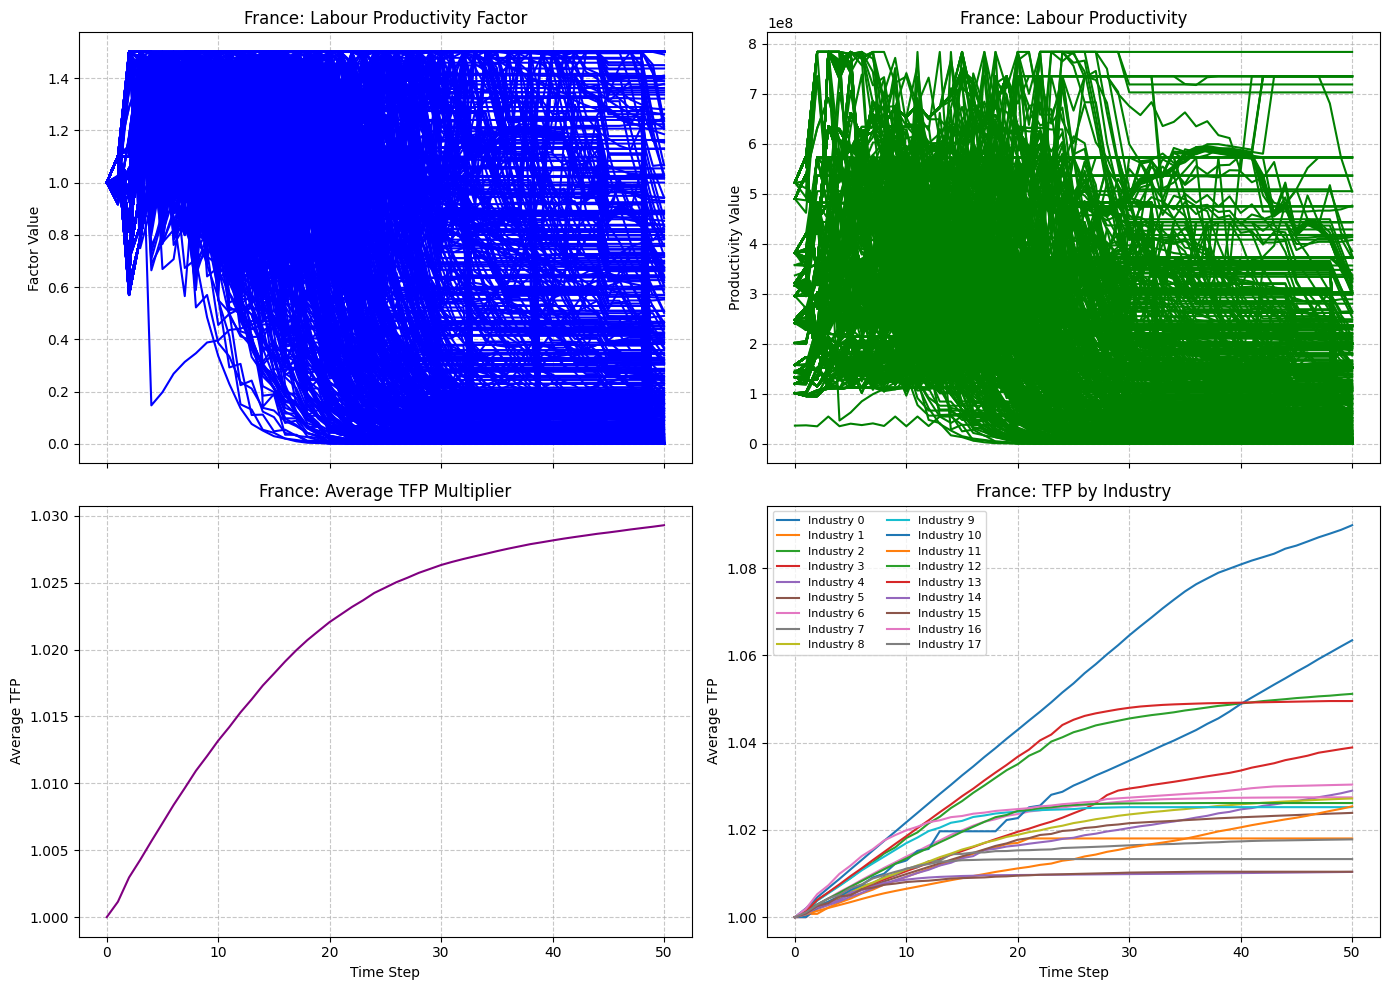

In [21]:
import numpy as np
import matplotlib.pyplot as plt

firms = benchmark.model.countries["FRA"].firms

avg_tfp_multiplier = np.array([np.mean(x) for x in firms.ts.tfp_multiplier])

tfp_by_industry = np.array([
    [
        np.mean(tfp[industry_mask]) if industry_mask.any() else np.nan
        for industry_mask in [
            firms.states["Industry"] == ind
            for ind in range(firms.n_industries)
        ]
    ]
    for tfp in firms.ts.tfp_multiplier
])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

ax1, ax2, ax3, ax4 = axes.ravel()

# Plot 1: Labour Productivity Factor
ax1.plot(firms.ts.labour_productivity_factor, color="blue")
ax1.set_title("France: Labour Productivity Factor")
ax1.set_ylabel("Factor Value")
ax1.grid(True, linestyle="--", alpha=0.7)

# Plot 2: Labour Productivity
ax2.plot(firms.ts.labour_productivity, color="green")
ax2.set_title("France: Labour Productivity")
ax2.set_ylabel("Productivity Value")
ax2.grid(True, linestyle="--", alpha=0.7)

# Plot 3: Average TFP Multiplier
ax3.plot(avg_tfp_multiplier, color="purple")
ax3.set_title("France: Average TFP Multiplier")
ax3.set_ylabel("Average TFP")
ax3.set_xlabel("Time Step")
ax3.grid(True, linestyle="--", alpha=0.7)

# Plot 4: TFP by Industry
for ind in range(firms.n_industries):
    ax4.plot(tfp_by_industry[:, ind], label=f"Industry {ind}")

ax4.set_title("France: TFP by Industry")
ax4.set_ylabel("Average TFP")
ax4.set_xlabel("Time Step")
ax4.grid(True, linestyle="--", alpha=0.7)
ax4.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


## Optional Monte Carlo

In [22]:
# Optional Monte Carlo
run_monte_carlo = False
mc_seeds = [19, 23, 27, 32, 37, 43, 54, 57, 71, 85, 98]

if run_monte_carlo:
    mc = run_seeded_monte_carlo(
        datawrapper=data,
        country_configurations=country_configurations,
        country_code=cfg.country_iso3,
        seeds=mc_seeds,
        t_max=cfg.t_max,
        n_jobs=-1,
        backend="loky",
        batch_size=1,
    )
    plot_mc(mc=mc, cols=fiscal_cols, no_rows=5, no_cols=4, country_code=cfg.country_iso3)
else:
    print("Set run_monte_carlo = True to run seeded Monte Carlo simulations.")

Set run_monte_carlo = True to run seeded Monte Carlo simulations.


## Optional Sensitivity

In [23]:
# Optional Sensitivity
run_sensitivity = False
# parameter_path = "firms.functions.labour_productivity.parameters['max_increase_in_work_effort']"
# parameter_values = np.linspace(1, 1.5, 10).tolist()

# "firms.functions.prices.parameters['price_setting_speed_dp']": 0.25,
# "firms.functions.prices.parameters['price_setting_speed_cp']": 0.25,
# override_path = "firms.functions.productivity_investment_planner.name"
# override_value = "SimpleProductivityInvestmentPlanner"
# parameter_path = "firms.functions.productivity_investment_planner.parameters['investment_effectiveness']"
# parameter_path = "banks.functions.demography.parameters['solvency_ratio']"
# parameter_path = "firms.functions.target_intermediate_inputs.parameters['target_intermediate_inputs_fraction']"
parameter_path = "firms.parameters.['intermediate_inputs_utilisation_rate']"
parameter_values = np.linspace(0.5, 1, 5).tolist()
# parameter_path = "firms.functions.productivity_investment_planner.parameters['cap_multiplier']"
# parameter_values = np.linspace(1, 5, 10).tolist()

mc_seeds = [19, 23, 27, 32, 37, 43, 54, 57, 71, 85, 98]

country_configurations = build_country_config(
    data=data,
    config=run_config,
    overrides=None,
)

if run_sensitivity:
    sensitivity = run_parameter_sensitivity(
        datawrapper=data,
        country_configurations=country_configurations,
        country_code=cfg.country_iso3,
        parameter_path=parameter_path,
        parameter_values=parameter_values,
        seeds=mc_seeds,
        t_max=cfg.t_max,
        n_jobs=-1,
        backend="loky",
        batch_size=1,
    )
    plot_sensitivity_summary(sensitivity, cols=plot_columns)
    plot_sensitivity(sensitivity, cols=plot_columns, no_rows=5, no_cols=5, country_code=cfg.country_iso3)
else:
    print("Set run_sensitivity = True to run parameter sensitivity simulations.")

Configuration summary
{'productivity_growth': 'SimpleTFPGrowth',
 'productivity_investment_planner': 'TargetIntensityTFPInvestmentPlanner',
 'labour_market': {'name': 'DefaultLabourMarketClearer',
                   'parameters': {'allow_switching_industries': True,
                                  'compare_with_normalised_inputs': True,
                                  'consider_reservation_wages': True,
                                  'firing_cost_fraction': 0.0,
                                  'firing_speed': 1.0,
                                  'hiring_cost_fraction': 0.0,
                                  'hiring_speed': 0.75,
                                  'individuals_quitting': False,
                                  'individuals_quitting_temperature': 1.0,
                                  'optimised_hiring': True,
                                  'random_firing_probability': 0.0,
                                  'round_target_employment': True,
                 

In [24]:
# plot_sensitivity_summary(sensitivity, cols=plot_columns)
plot_sensitivity(sensitivity, cols=['bank_insolvency_rate'], no_rows=2, no_cols=2, country_code=cfg.country_iso3, base_height=400, base_width=600)


NameError: name 'sensitivity' is not defined

In [ ]:
plot_sensitivity(sensitivity, cols=['avg_tfp_multiplier'], no_rows=1, no_cols=2, country_code=cfg.country_iso3, base_height=600, base_width=600)


# Appendix

Scratch diagnostics and notes. These cells are not part of the main top-to-bottom workflow.

### Government consumption behaviour

| Setter | Total-consumption anchor | Growth source | Uses exogenous gov path? | Uses `expected_growth`? | Price adjustment | Sector allocation | Key assumption / caveat |
|---|---|---|---|---|---|---|---|
| `AutoregressiveGovernmentConsumptionSetter` | Forecasted total government consumption `C_t` from AR on historical total consumption | `ManualAutoregForecaster()` on `historic_total_consumption` or `log(historic_total_consumption)` in `macromodel/agents/government_entities/func/consumption.py:171` | No, not directly for the forecast itself; exogenous pre-sample history can be included in `historic_total_consumption` via `macromodel/agents/government_entities/government_entities.py:212` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:205` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:209` | Total is forecasted, but sector shares drift through recursive reweighting with relative prices |
| `ConstantGrowthGovernmentConsumptionSetter` | Previous desired government consumption vector scaled forward each period | Either configured `default_growth`, or estimated once as mean log growth of `historic_total_consumption` in `macromodel/agents/government_entities/func/consumption.py:277` | No | No | Yes: when history exists, uses `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:287` | Implicitly last period’s desired nominal vector, because the whole vector is scaled in `macromodel/agents/government_entities/func/consumption.py:290` | “Constant growth” is literal after initialization; estimated growth is log-growth but later applied as arithmetic growth `(1 + g)`, which is not fully consistent |
| `ExogenousGovernmentConsumptionSetter` | Exogenous total real government consumption path `exogenous_total_consumption[t]` | No endogenous growth estimation; the level comes directly from exogenous national accounts path | Yes: `self.exogenous.national_accounts_during["Real Government Consumption (Value)"]` passed from `macromodel/country/country.py:934` | No | Yes: multiplies by `(1 + expected_inflation) * current_good_prices / initial_good_prices` in `macromodel/agents/government_entities/func/consumption.py:477` | Previous desired spending shares `previous_desired_government_consumption / sum(...)` in `macromodel/agents/government_entities/func/consumption.py:481` | Aggregate path is exogenous, but composition is still endogenous via lagged shares; if exogenous data ends, it raises an error; if exogenous path is missing entirely, it falls back to configured `default_growth` |


### Readers

In [ ]:
# gov consumption estimation

import numpy as np
from macromodel.forecaster.forecaster import ManualAutoregForecaster

country = model.countries[cfg.country_iso3]
ge = country.government_entities

exog_before = country.exogenous.national_accounts_before["Real Government Consumption (Value)"].values.flatten()

historic_ppi = np.array(country.economy.ts.historic("ppi")).flatten()

historic_total_consumption = np.concatenate(
    (
        exog_before[-country.forecasting_window:],
        np.array(ge.ts.historic("total_consumption")).flatten() / historic_ppi,
    )
)

series = np.log(historic_total_consumption)
series = series[np.isfinite(series)]

var = ManualAutoregForecaster.rfvar3(series, np.ones((len(series), 1)))

phi = var["By"][0][0][0]
intercept = var["Bx"][0]
resid_std = np.sqrt(np.var(var["u"]))
n_obs = len(series) - 1

phi, intercept, resid_std, n_obs


In [ ]:
from src.helpers import fit_social_benefits_arx_diagnostics
from macro_data.readers.default_readers import DataReaders
from macro_data.readers import AGGREGATED_INDUSTRIES, ALL_INDUSTRIES

country_names = data_config.countries
industries = AGGREGATED_INDUSTRIES if data_config.aggregate_industries else ALL_INDUSTRIES
scale_dict = {country: data_config.country_configs[country].scale for country in country_names}
proxy_country_dict = {
    country: data_config.country_configs[country].eu_proxy_country
    for country in data_config.countries
    if not country.is_eu_country
}

readers = DataReaders.from_raw_data(
    raw_data_path=cfg.raw_data_path,
    country_names=country_names,
    simulation_year=data_config.year,
    scale_dict=scale_dict,
    industries=industries,
    aggregate_industries=data_config.aggregate_industries,
    prune_date=data_config.prune_date,
    force_single_hfcs_survey=False,
    single_icio_survey=True,
    proxy_country_dict=proxy_country_dict,
    use_disagg_can_2014_reader=data_config.can_disaggregation,
    use_provincial_can_reader=False,
    regions_dict=None,
    allow_missing_emissions=False,
)


In [ ]:
country_iso3 = cfg.country_iso3   # e.g. "FRA"
year = data_config.year
quarter = data_config.quarter
time_unit = data_config.time_unit  # e.g. 3 for quarterly
periods_per_year = 12 // time_unit
quarter_key = f"{year}-Q{quarter}"


firm_rates_annual = readers.ecb_reader.get_firm_rates(country_iso3)
hh_cons_rates_annual = readers.ecb_reader.get_household_consumption_rates(country_iso3)
hh_mort_rates_annual = readers.ecb_reader.get_household_mortgage_rates(country_iso3)
policy_rates_annual = readers.policy_rates.get_policy_rates(country_iso3)

firm_rates_annual.loc[quarter_key]
hh_cons_rates_annual.loc[quarter_key]
hh_mort_rates_annual.loc[quarter_key]
policy_rates_annual.loc[quarter_key, "Policy Rate"]


In [ ]:
country = cfg.country_iso3
quarter_key = f"{2022}-Q{data_config.quarter}"
periods_per_year = 12 // data_config.time_unit

banks = data.synthetic_countries[country].banks

firm_rate_annual = readers.ecb_reader.get_firm_rates(country).loc[quarter_key].iloc[0]
hh_cons_rate_annual = readers.ecb_reader.get_household_consumption_rates(country).loc[quarter_key].iloc[0]
hh_mort_rate_annual = readers.ecb_reader.get_household_mortgage_rates(country).loc[quarter_key].iloc[0]
policy_rate_annual = readers.policy_rates.get_policy_rates(country).loc[quarter_key, "Policy Rate"].iloc[0]

comparison = pd.DataFrame(
    {
        "raw_annual_reader": [
            float(firm_rate_annual),
            float(hh_cons_rate_annual),
            float(hh_mort_rate_annual),
            float(policy_rate_annual),
            float(policy_rate_annual),
        ],
        "expected_per_period": [
            float(firm_rate_annual) / periods_per_year,
            float(hh_cons_rate_annual) / periods_per_year,
            float(hh_mort_rate_annual) / periods_per_year,
            float(policy_rate_annual) / periods_per_year,
            float(policy_rate_annual) / periods_per_year,
        ],
        "stored_in_data": [
            float(banks.firm_rate),
            float(banks.hh_consumption_rate),
            float(banks.hh_mortgage_rate),
            float(banks.bank_data["Interest Rates on Firm Deposits"].iloc[0]),
            float(banks.bank_data["Interest Rates on Household Deposits"].iloc[0]),
        ],
    },
    index=[
        "firm loan rate",
        "hh consumption loan rate",
        "mortgage rate",
        "firm deposit rate",
        "hh deposit rate",
    ],
)

comparison["difference"] = comparison["stored_in_data"] - comparison["expected_per_period"]
comparison


In [ ]:
import pandas as pd

country = cfg.country_iso3
quarter_key = f"{data_config.year}-Q{data_config.quarter}"
periods_per_year = 12 // data_config.time_unit

def scalar(x):
    if isinstance(x, pd.DataFrame):
        return x.iloc[0, 0]
    if isinstance(x, pd.Series):
        return x.iloc[0]
    return x

synthetic_country = data.synthetic_countries[country]
banks = synthetic_country.banks
cb_data = synthetic_country.central_bank.central_bank_data

policy_rate_raw_annual = float(scalar(readers.policy_rates.get_policy_rates(country).loc[quarter_key, ["Policy Rate"]]))
firm_loan_raw_annual = float(scalar(readers.ecb_reader.get_firm_rates(country).loc[quarter_key]))
hh_cons_loan_raw_annual = float(scalar(readers.ecb_reader.get_household_consumption_rates(country).loc[quarter_key]))
mortgage_raw_annual = float(scalar(readers.ecb_reader.get_household_mortgage_rates(country).loc[quarter_key]))

rows = [
    ["policy rate from reader", policy_rate_raw_annual, policy_rate_raw_annual / periods_per_year, None],
    ["central bank stored policy_rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(cb_data[["policy_rate"]])) if "policy_rate" in cb_data.columns else None],
    ["central bank stored smooth_policy_rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(cb_data[["smooth_policy_rate"]])) if "smooth_policy_rate" in cb_data.columns else None],
    ["firm deposit rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(banks.bank_data[["Interest Rates on Firm Deposits"]]))],
    ["household deposit rate", None, policy_rate_raw_annual / periods_per_year, float(scalar(banks.bank_data[["Interest Rates on Household Deposits"]]))],
    ["firm loan rate", firm_loan_raw_annual, firm_loan_raw_annual / periods_per_year, float(banks.firm_rate)],
    ["hh consumption loan rate", hh_cons_loan_raw_annual, hh_cons_loan_raw_annual / periods_per_year, float(banks.hh_consumption_rate)],
    ["mortgage rate", mortgage_raw_annual, mortgage_raw_annual / periods_per_year, float(banks.hh_mortgage_rate)],
]

df_rates = pd.DataFrame(rows, columns=["rate", "raw_annual", "expected_per_period", "stored_in_data"])
df_rates["stored_minus_expected"] = df_rates["stored_in_data"] - df_rates["expected_per_period"]

print(f"country={country}, quarter={quarter_key}, time_unit={data_config.time_unit}, periods_per_year={periods_per_year}")
print(df_rates.round(6).to_string(index=False))


In [ ]:
import pandas as pd

country = cfg.country_iso3
start_period = pd.Period(f"{data_config.year}Q{data_config.quarter}", freq="Q")
init_period = start_period - 1
init_key = f"{init_period.year}-Q{init_period.quarter}"
periods_per_year = 12 // data_config.time_unit

synthetic_country = data.synthetic_countries[country]
cb_data = synthetic_country.central_bank.central_bank_data
banks = synthetic_country.banks

policy_rate_init_annual = float(readers.policy_rates.get_policy_rates(country).loc[init_key, ["Policy Rate"]].iloc[0, 0])
policy_rate_init_period = policy_rate_init_annual / periods_per_year

check = pd.DataFrame(
    [
        ["pre-start policy rate from reader", policy_rate_init_annual, policy_rate_init_period, None],
        ["stored smooth_policy_rate", None, policy_rate_init_period, float(cb_data["smooth_policy_rate"].iloc[0]) if "smooth_policy_rate" in cb_data.columns else None],
        ["stored legacy policy_rate", None, policy_rate_init_period, float(cb_data["policy_rate"].iloc[0]) if "policy_rate" in cb_data.columns else None],
        ["firm deposit rate", None, policy_rate_init_period, float(banks.bank_data["Interest Rates on Firm Deposits"].iloc[0])],
        ["household deposit rate", None, policy_rate_init_period, float(banks.bank_data["Interest Rates on Household Deposits"].iloc[0])],
    ],
    columns=["rate", "raw_annual", "expected_per_period", "stored_in_data"],
)

check["stored_minus_expected"] = check["stored_in_data"] - check["expected_per_period"]
print(f"start={start_period}, init={init_key}, time_unit={data_config.time_unit}")
print(check.round(6).to_string(index=False))


# Notes: CBC7

- UK baseline (lots of small edits)
- Synthetic population script mimicking HFCS for the UK. Testing it currently.
- Marcela updated the starting year
- Monte Carlo runs + dashboard
- prehooks for shock
- Marcela tested 1-to-1 simulation


In [ ]:
# CBC7 issues

# UK baseline (lots of small edits)
# Synthetic population script mimicking HFCS for the UK. Testing it currently.
# Marcela updated the starting year
# Monte Carlo runs + dashboard
# prehooks for shock
# Marcela tested 1-to-1 simulation
